In [ ]:
import mcstasscript as ms
import mcstastox as mx
import scipp as sc
from scipp.typing import VariableLike
import scipp as sc
import matplotlib.pyplot as plt
import numpy as np
from scippneutron.conversion.graph.beamline import beamline

import os


import sys 
current = os.getcwd()
sys.path.append(current + "/trex_data_reduction")
from trex_reduction import inelastic
from trex_reduction import produce_trex_event_object, v_bin_norm

In [26]:
file_path = "/Users/bb24144/Documents/McStas/reduction_plet/mcstas_to_scipp/run_benzene/ISIS_LET_generated_prod_2e11"

with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp_simple(source_name="SourceMantid",
                                            sample_name="iso_samp")
    
# Load event data into scipp 
event_object = scipp_object
# McStas provides absolute time, not time of flight
event_object.coords["tof"] = event_object.coords["t"]
# Add additional information required for inelastic scattering
event_object = produce_trex_event_object(event_object, file_path, "Monitor6")
event_object

<scipp.DataArray>
Dimensions: Sizes[events:26862075, ]
Coordinates:
* monitor_position          vector3              [m]  ()  (0, 0, 23.505)
* position                  vector3              [m]  (events)  [(3.1194, 1.16176, 26.5872), (0.267855, -1.69118, 28.4897), ..., (3.47676, 0.691176, 25.4027), (3.26165, -0.808824, 26.2695)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.0338995, 0.0331797, ..., 0.0346019, 0.0338487]
* time_on_monitor           float64              [s]  (events)  [0.0280169, 0.0280169, ..., 0.0280169, 0.0280169]
* tof                       float64              [s]  (events)  [0.0338995, 0.0331797, ..., 0.0346019, 0.0338487]
Data:
                            float64         [counts]  (events)  [2.3614e-06, 2.5205e-06, ..., 4.2796e-06, 4.05793e-06]

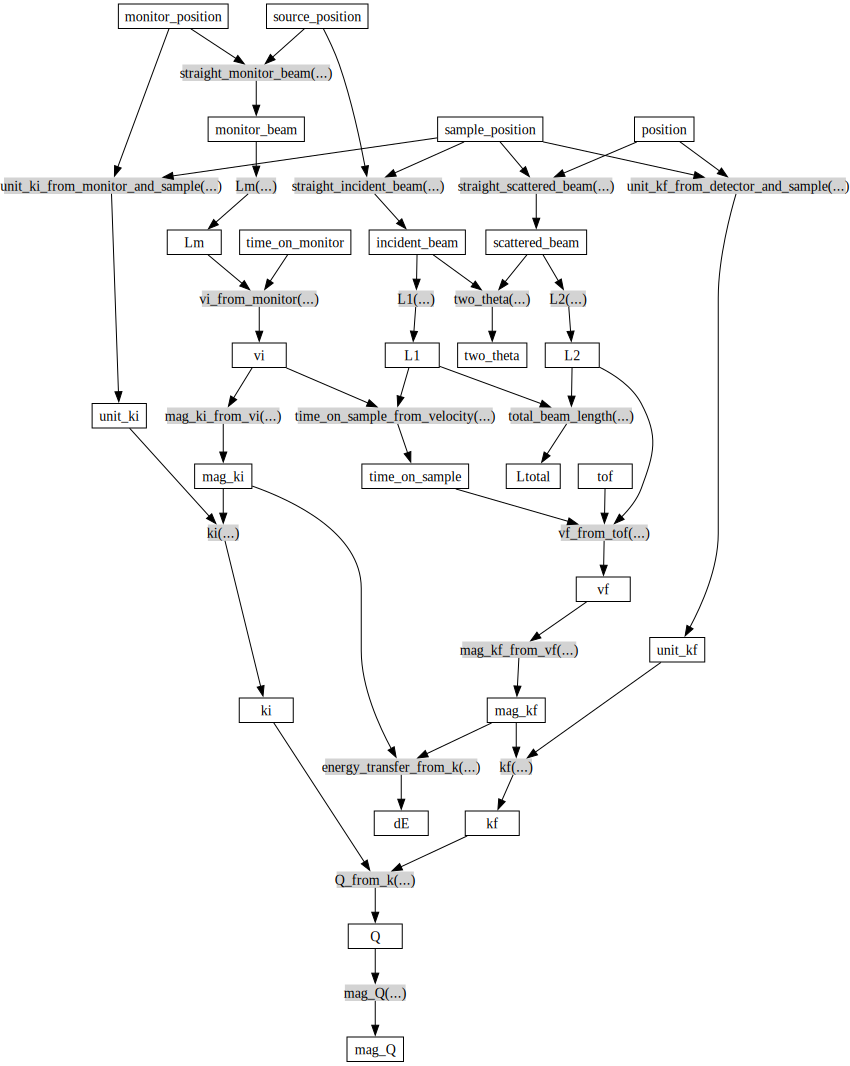

In [27]:
qens_graph = {**beamline(scatter=True), **inelastic}
sc.show_graph(qens_graph)

In [28]:
event_object = event_object.transform_coords("dE", graph=qens_graph)
event_object = event_object.transform_coords("mag_Q", graph=qens_graph)
event_object = event_object.transform_coords("two_theta", graph=qens_graph)

event_object

<scipp.DataArray>
Dimensions: Sizes[events:26862075, ]
Coordinates:
  L1                        float64              [m]  ()  25
  L2                        float64              [m]  (events)  [3.68778, 3.88717, ..., 3.56759, 3.59224]
  Lm                        float64              [m]  ()  23.505
  Q                         vector3           [1/Å]  (events)  [(-1.20822, -0.449979, 0.717699), (-0.125834, 0.79449, -0.306951), ..., (-1.1497, -0.228558, 1.19932), (-1.27916, 0.317207, 0.8346)]
* dE                        float64            [meV]  (events)  [-0.548559, -3.23102, ..., 0.795121, -0.433635]
  incident_beam             vector3              [m]  ()  (0, 0, 25)
  kf                        vector3           [1/Å]  (events)  [(1.20822, 0.449979, 0.614777), (0.125834, -0.79449, 1.63943), ..., (1.1497, 0.228558, 0.133153), (1.27916, -0.317207, 0.497876)]
  ki                        vector3           [1/Å]  (events)  [(0, 0, 1.33248), (0, 0, 1.33248), ..., (0, 0, 1.33248), (0, 0, 1.33248)]
* mag_Q                     float64           [1/Å]  (events)  [1.47559, 0.860969, ..., 1.67703, 1.55995]
  mag_kf                    float64           [1/Å]  (events)  [1.42836, 1.82614, ..., 1.17973, 1.40882]
  mag_ki                    float64           [1/Å]  (events)  [1.33248, 1.33248, ..., 1.33248, 1.33248]
  monitor_beam              vector3              [m]  ()  (0, 0, 23.505)
  monitor_position          vector3              [m]  ()  (0, 0, 23.505)
  position                  vector3              [m]  (events)  [(3.1194, 1.16176, 26.5872), (0.267855, -1.69118, 28.4897), ..., (3.47676, 0.691176, 25.4027), (3.26165, -0.808824, 26.2695)]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  scattered_beam            vector3              [m]  (events)  [(3.1194, 1.16176, 1.58724), (0.267855, -1.69118, 3.48974), ..., (3.47676, 0.691176, 0.402664), (3.26165, -0.808824, 1.2695)]
  source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.0338995, 0.0331797, ..., 0.0346019, 0.0338487]
  time_on_monitor           float64              [s]  (events)  [0.0280169, 0.0280169, ..., 0.0280169, 0.0280169]
  time_on_sample            float64              [s]  (events)  [0.0297989, 0.0297989, ..., 0.0297989, 0.0297989]
  tof                       float64              [s]  (events)  [0.0338995, 0.0331797, ..., 0.0346019, 0.0338487]
* two_theta                 float64            [rad]  (events)  [1.12585, 0.456144, ..., 1.45769, 1.20959]
  unit_kf                   vector3  [dimensionless]  (events)  [(0.845876, 0.315031, 0.430406), (0.0689075, -0.435066, 0.897758), ..., (0.974539, 0.193737, 0.112867), (0.907971, -0.225158, 0.3534)]
  unit_ki                   vector3  [dimensionless]  ()  (0, 0, 1)
  vf                        float64            [m/s]  (events)  [899.33, 1149.78, ..., 742.786, 887.022]
  vi                        float64            [m/s]  (events)  [838.957, 838.957, ..., 838.957, 838.957]
Data:
                            float64         [counts]  (events)  [2.3614e-06, 2.5205e-06, ..., 4.2796e-06, 4.05793e-06]

# Vanad load and transform

In [29]:
vanad_path = "/Users/bb24144/Documents/McStas/reduction_plet/mcstas_to_scipp/run_benzene/vanad_prod_2e11"


with mx.Read(vanad_path) as loaded_data:
    scipp_object = loaded_data.export_scipp_simple(source_name="SourceMantid",
                                            sample_name="iso_samp")
    
data = ms.load_data(vanad_path)

vanad_event = scipp_object
vanad_event.coords["tof"] = vanad_event.coords["t"]
vanad_event = produce_trex_event_object(vanad_event, file_path, "Monitor6")


vanad_event = vanad_event.transform_coords("dE", graph=qens_graph)
vanad_event = vanad_event.transform_coords("mag_Q", graph=qens_graph)
vanad_event = vanad_event.transform_coords("two_theta", graph=qens_graph)

vanad_event

<scipp.DataArray>
Dimensions: Sizes[events:3274404, ]
Coordinates:
  L1                        float64              [m]  ()  25
  L2                        float64              [m]  (events)  [3.87446, 3.8137, ..., 3.65242, 3.55155]
  Lm                        float64              [m]  ()  23.505
  Q                         vector3           [1/Å]  (events)  [(-0.0409783, 0.57304, 0.126238), (0.0107032, -0.533213, 0.100439), ..., (0.246223, 0.382007, 0.0758396), (0.626365, 0.228416, 0.163823)]
* dE                        float64            [meV]  (events)  [-0.0198347, -0.0556428, ..., -0.0211318, -0.072039]
  incident_beam             vector3              [m]  ()  (0, 0, 25)
  kf                        vector3           [1/Å]  (events)  [(0.0409783, -0.57304, 1.20624), (-0.0107032, 0.533213, 1.23204), ..., (-0.246223, -0.382007, 1.25664), (-0.626365, -0.228416, 1.16865)]
  ki                        vector3           [1/Å]  (events)  [(0, 0, 1.33248), (0, 0, 1.33248), ..., (0, 0, 1.33248), (0, 0, 1.33248)]
* mag_Q                     float64           [1/Å]  (events)  [0.588209, 0.542695, ..., 0.460768, 0.686546]
  mag_kf                    float64           [1/Å]  (events)  [1.33606, 1.34251, ..., 1.3363, 1.34546]
  mag_ki                    float64           [1/Å]  (events)  [1.33248, 1.33248, ..., 1.33248, 1.33248]
  monitor_beam              vector3              [m]  ()  (0, 0, 23.505)
  monitor_position          vector3              [m]  ()  (0, 0, 23.505)
  position                  vector3              [m]  (events)  [(0.118833, -1.66176, 28.498), (-0.0304047, 1.51471, 28.4999), ..., (-0.672986, -1.04412, 28.4347), (-1.65339, -0.602941, 28.0848)]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  scattered_beam            vector3              [m]  (events)  [(0.118833, -1.66176, 3.49798), (-0.0304047, 1.51471, 3.49987), ..., (-0.672986, -1.04412, 3.43469), (-1.65339, -0.602941, 3.08485)]
  source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.0344047, 0.0343107, ..., 0.03414, 0.0339914]
  time_on_monitor           float64              [s]  (events)  [0.0280169, 0.0280169, ..., 0.0280169, 0.0280169]
  time_on_sample            float64              [s]  (events)  [0.0297989, 0.0297989, ..., 0.0297989, 0.0297989]
  tof                       float64              [s]  (events)  [0.0344047, 0.0343107, ..., 0.03414, 0.0339914]
* two_theta                 float64            [rad]  (events)  [0.44449, 0.408523, ..., 0.34703, 0.518444]
  unit_kf                   vector3  [dimensionless]  (events)  [(0.0306709, -0.428902, 0.90283), (-0.00797248, 0.397175, 0.917708), ..., (-0.184257, -0.28587, 0.940387), (-0.46554, -0.169768, 0.868591)]
  unit_ki                   vector3  [dimensionless]  ()  (0, 0, 1)
  vf                        float64            [m/s]  (events)  [841.215, 845.277, ..., 841.363, 847.131]
  vi                        float64            [m/s]  (events)  [838.957, 838.957, ..., 838.957, 838.957]
Data:
                            float64         [counts]  (events)  [6.4986e-47, 2.3461e-05, ..., 2.91734e-31, 9.94531e-07]

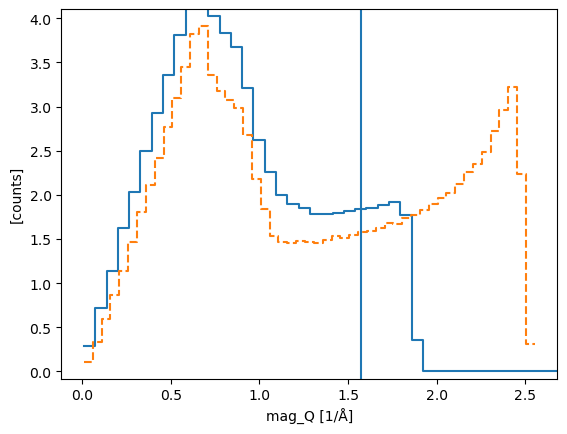

In [30]:
fig, ax = plt.subplots()
(event_object.hist(mag_Q=51)).plot(ax=ax, linestyle='-', color='tab:blue')
(vanad_event.hist(mag_Q=51)).plot(ax=ax, linestyle='--', color='tab:orange')
ax.axvline(np.pi/2)
# (event_object.hist(theta_test=51)).plot(ax=ax, linestyle='--', color='tab:orange')
plt.show()

In [31]:
new_q = sc.linspace('mag_Q', 0.6,1.8,num=20, unit = '1/Angstrom')
new_omega = sc.linspace('dE', -2,2,num=300, unit = 'meV')

bin_list = [new_q,new_omega]

hist_event, hist_vanad, hist_norm = v_bin_norm(bin_list,event_object, vanad_event)

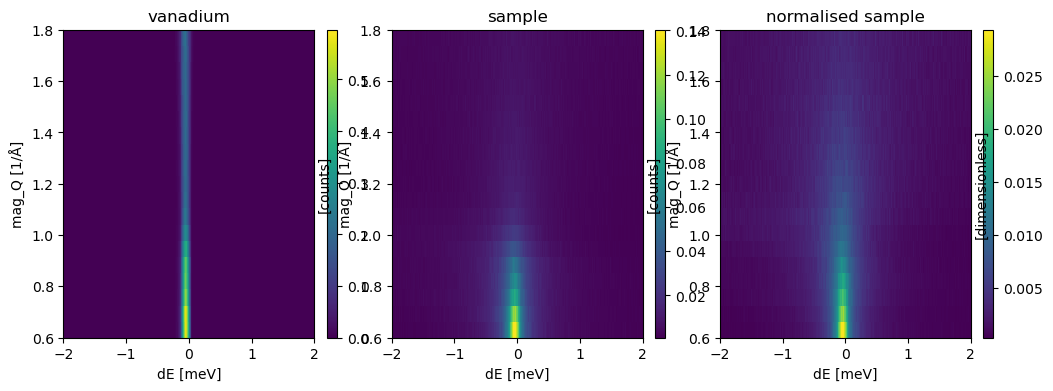

In [32]:
fig, [ax1,ax2,ax3] = plt.subplots(1,3,figsize =(12,4))


hist_vanad.plot(ax=ax1)
hist_event.plot(ax=ax2)
hist_norm.plot(ax=ax3)

ax1.set_title('vanadium')
ax2.set_title('sample')
ax3.set_title('normalised sample')
plt.show()

/var/folders/8y/ppth74md47d_wyx004p8vy6h0000gp/T/ipykernel_64074/705522590.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


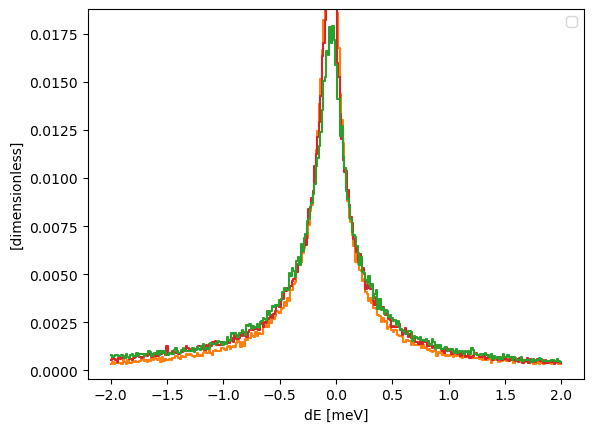

In [33]:
fig, ax = plt.subplots()

col = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green']

for i in range(1,4,1):
    hist_norm['mag_Q', i].plot(ax=ax, color = col[i])
    ax.legend()


In [34]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("/Users/bb24144/Documents/McStas/reduction_plet/plet")
from plet_data import PletData

plet_data = PletData('/Users/bb24144/Documents/McStas/reduction_plet/trex_data_reduction/plet_data/benzene_290_360_inc.nxspe', 3.60, omega_lims = [-4,4], q_lims = [0.4,1.8])

In [35]:
new_q_plet = sc.linspace('q', 0.6,1.8,num=20, unit = '1/Angstrom')
new_omega_plet = sc.linspace('omega', -2,2,num=300, unit = 'meV')

plet_data.data = plet_data.data.rebin(q = new_q_plet, omega = new_omega_plet)

In [36]:
hist_event

<scipp.DataArray>
Dimensions: Sizes[mag_Q:19, dE:299, ]
Coordinates:
  L1                        float64              [m]  ()  25
  Lm                        float64              [m]  ()  23.505
* dE                        float64            [meV]  (dE [bin-edge])  [-2, -1.98662, ..., 1.98662, 2]
  incident_beam             vector3              [m]  ()  (0, 0, 25)
* mag_Q                     float64           [1/Å]  (mag_Q [bin-edge])  [0.6, 0.663158, ..., 1.73684, 1.8]
  monitor_beam              vector3              [m]  ()  (0, 0, 23.505)
  monitor_position          vector3              [m]  ()  (0, 0, 23.505)
  sample_position           vector3              [m]  ()  (0, 0, 25)
  source_position           vector3              [m]  ()  (0, 0, 0)
  unit_ki                   vector3  [dimensionless]  ()  (0, 0, 1)
Data:
                            float64         [counts]  (mag_Q, dE)  [0.00165616, 0.00153503, ..., 0.00281831, 0.0033256]

In [37]:
plet_data.data.coords['q']

<scipp.Variable> (q: 20)    float64           [1/Å]  [0.6, 0.663158, ..., 1.73684, 1.8]

/var/folders/8y/ppth74md47d_wyx004p8vy6h0000gp/T/ipykernel_64074/877553439.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


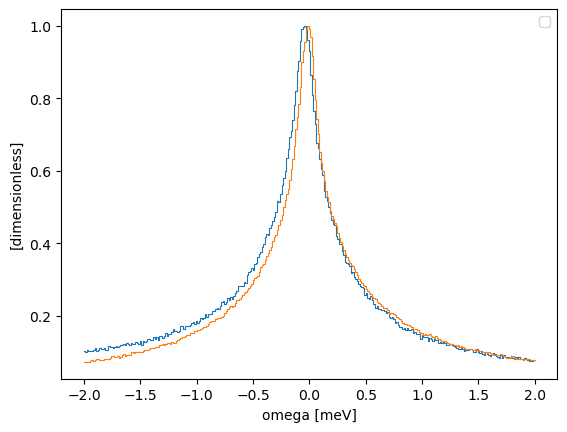

In [38]:
fig, ax = plt.subplots()

summed = sc.nansum(plet_data.data, dim='q')
summed_no_var = sc.values(summed)  # drops variances, keeps values


(sc.nansum(hist_norm, dim = 'mag_Q') / sc.nansum(hist_norm, dim = 'mag_Q').max()).plot(ax = ax, linewidth=0.8)
(summed_no_var / summed_no_var.max()).plot(ax=ax, linewidth=0.8, color = 'tab:orange')
#ax.stairs(plet_data.data.nansum('q').values / (np.max(plet_data.data.nansum('q').values)), plet_data.data.coords['omega'].values, label = 'pLET-exp')
ax.legend()
plt.show()

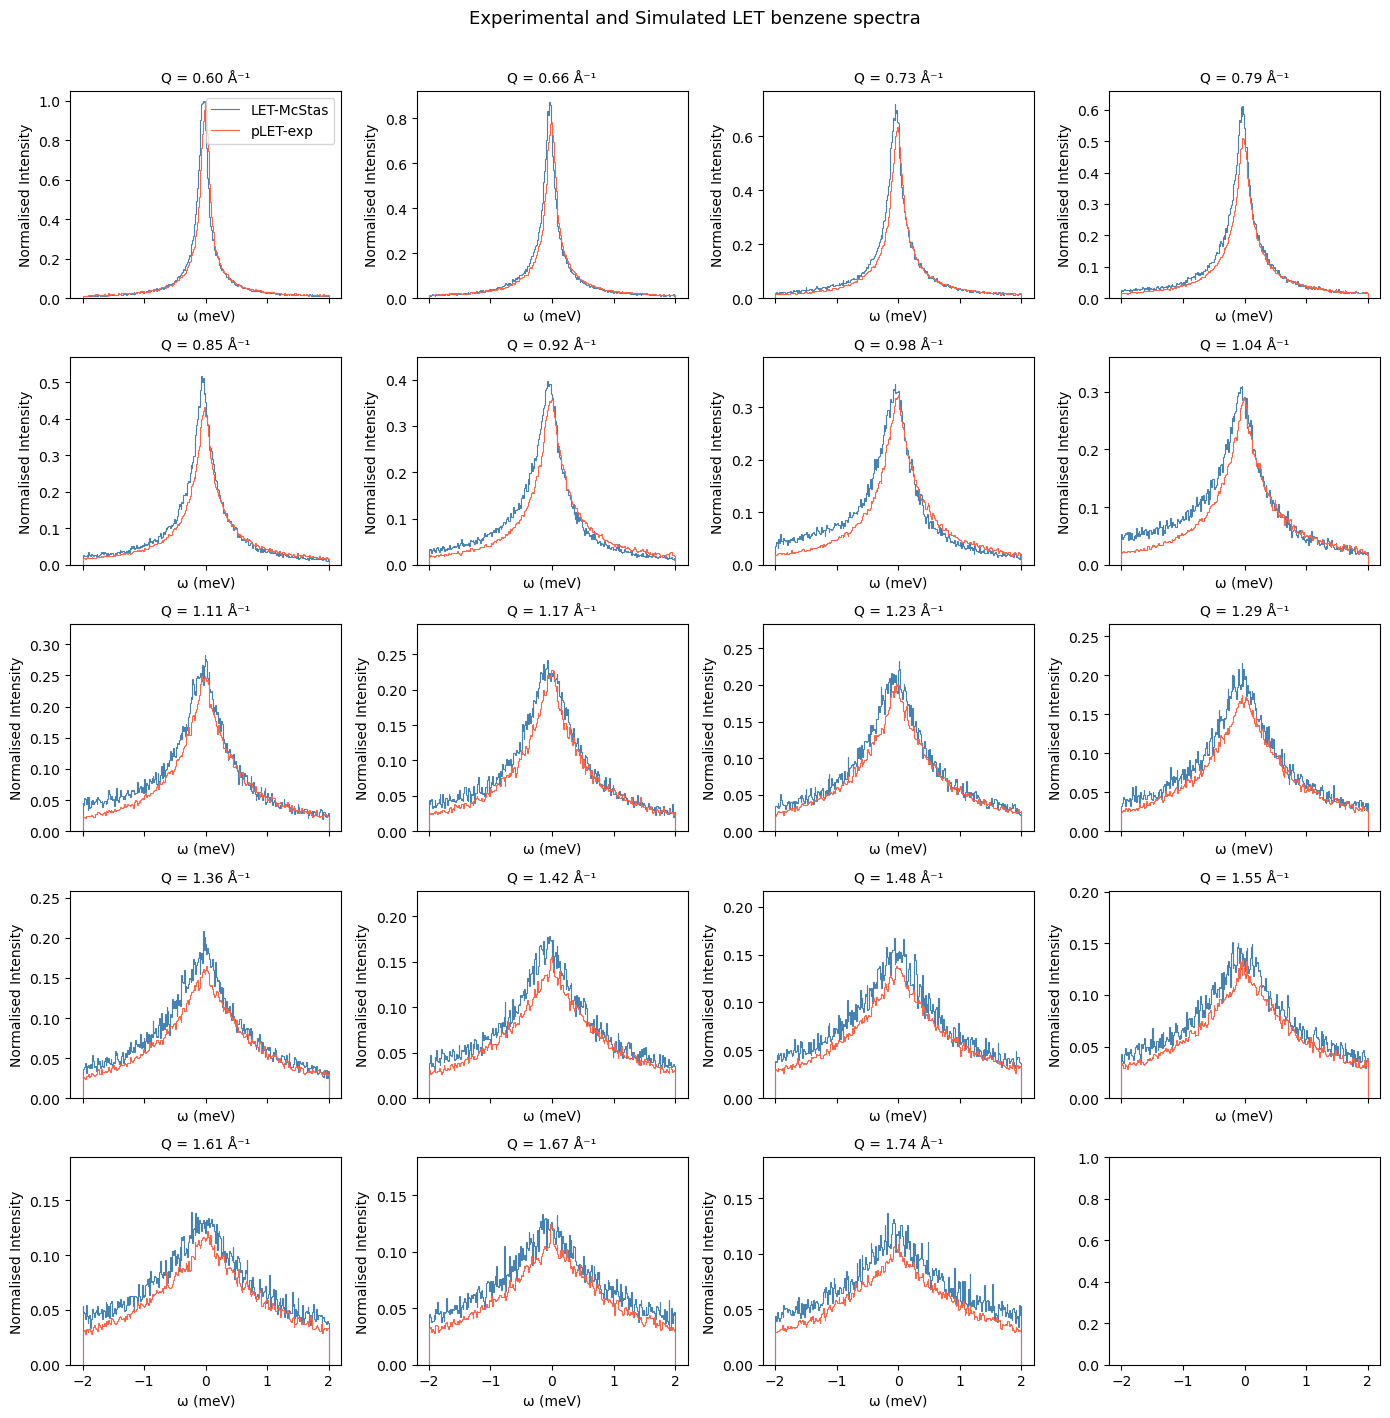

In [39]:
q_values = plet_data.data.coords['q'].values
n_q = hist_norm.sizes['mag_Q']  # use hist_norm's actual Q size, not plet's coords

ncols = 4
nrows = int(np.ceil(n_q / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8),
                          sharex=True)
axes = axes.flatten()

for i in range(n_q):  # index-based, safe for both
    ax = axes[i]

    hist_slice = hist_norm['mag_Q', i]
    plet_slice = plet_data.data['q', i]
    plet_vals = plet_slice.values

    if i == 0:
        norm_scaler = sc.scalar(hist_slice.values.max())
        plet_scaler = np.nanmax(plet_vals)


    # --- hist_norm ---
    
    hist_norm1d = hist_slice / norm_scaler
    ax.stairs(hist_norm1d.values,
          hist_norm1d.coords['dE'].values,
          color='steelblue', linewidth=0.8, label='LET-McStas')

    # --- plet ---
    plet_norm = plet_vals / plet_scaler
    ax.stairs(plet_norm,
              plet_data.data.coords['omega'].values,
              color='tomato', linewidth=0.8, label='pLET-exp')

    q_val = q_values[i]

    ax.set_title(f'Q = {q_val:.2f} Å⁻¹', fontsize=10)
    ax.set_ylim(0,np.nanmax(hist_norm1d.values)+0.05)
    ax.set_ylabel('Normalised Intensity')
    ax.set_xlabel('ω (meV)')

# # Hide unused panels
# for j in range(n_q, len(axes)):
#     axes[j].set_visible(False)



axes[0].legend(loc='upper right', fontsize=10)

fig.suptitle('Experimental and Simulated LET benzene spectra', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [40]:
hist_norm

<scipp.DataArray>
Dimensions: Sizes[mag_Q:19, dE:299, ]
Coordinates:
  L1                        float64              [m]  ()  25
  Lm                        float64              [m]  ()  23.505
* dE                        float64            [meV]  (dE [bin-edge])  [-2, -1.98662, ..., 1.98662, 2]
  incident_beam             vector3              [m]  ()  (0, 0, 25)
* mag_Q                     float64           [1/Å]  (mag_Q [bin-edge])  [0.6, 0.663158, ..., 1.73684, 1.8]
  monitor_beam              vector3              [m]  ()  (0, 0, 23.505)
  monitor_position          vector3              [m]  ()  (0, 0, 23.505)
  sample_position           vector3              [m]  ()  (0, 0, 25)
  source_position           vector3              [m]  ()  (0, 0, 0)
  unit_ki                   vector3  [dimensionless]  ()  (0, 0, 1)
Data:
                            float64  [dimensionless]  (mag_Q, dE)  [0.000346331, 0.000321, ..., 0.00131834, 0.00155563]

In [41]:
plet_data.data

<scipp.DataArray>
Dimensions: Sizes[q:19, omega:299, ]
Coordinates:
* omega                     float64            [meV]  (omega [bin-edge])  [-2, -1.98662, ..., 1.98662, 2]
* q                         float64           [1/Å]  (q [bin-edge])  [0.6, 0.663158, ..., 1.73684, 1.8]
Data:
                            float64  [dimensionless]  (q, omega)  [0.859984, 0.758152, ..., 2.32583, 2.27623]  [0.0668321, 0.0609435, ..., 0.0421108, 0.042296]

In [42]:
q_mid = plet_data.data.coords['q'].values[0:-1] + np.diff(plet_data.data.coords['q'].values)/2 
q_mid

array([0.63157895, 0.69473684, 0.75789474, 0.82105263, 0.88421053,
       0.94736842, 1.01052632, 1.07368421, 1.13684211, 1.2       ,
       1.26315789, 1.32631579, 1.38947368, 1.45263158, 1.51578947,
       1.57894737, 1.64210526, 1.70526316, 1.76842105])

In [43]:
plet_data.data.coords['omega']

<scipp.Variable> (omega: 300)    float64            [meV]  [-2, -1.98662, ..., 1.98662, 2]

In [44]:
plet_int = np.zeros(19)
mc_int = np.zeros(19)   
vad_int = np.zeros(19)


for i in range(len(plet_data.data.coords['q']) - 1):
   plet_int[i] =  np.trapezoid(plet_data.data['q', i].values)
   mc_int[i] = np.trapezoid(hist_norm['mag_Q', i].values)
   vad_int[i] = np.trapezoid(hist_vanad['mag_Q', i].values)

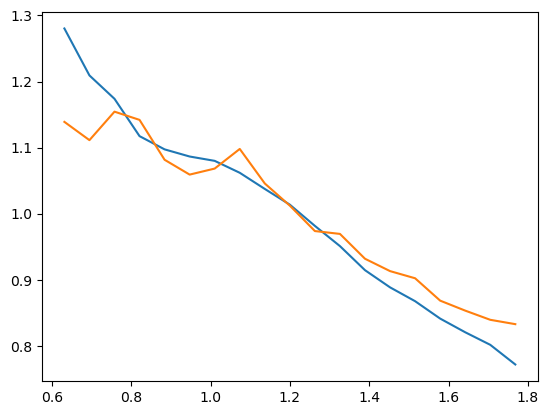

In [45]:
plt.plot(q_mid, plet_int / np.mean(plet_int))
plt.plot(q_mid, mc_int / np.mean(mc_int)) 

In [ ]:
def second_moment_analyser(energy, s_qw, s_qw_err = None):
    """
    Calculate the second moment of S(q,ω).

    Parameters|
    ----------
    energy: ndarray
         Array of energy values.
    s_qw: ndarray
        2D array where each row corresponds to the scattering function at a specific energy.

    Returns
    ----------
        second_moment: ndarray
            Array of second moment values as a function of q
    """
    s_qe = np.zeros(s_qw.shape[0])
    e2s_qe = np.zeros(s_qw.shape[0])

    if s_qw_err is not None:
        err_total = np.zeros(s_qw.shape[0])


    for i, sqw in enumerate(s_qw):
        s_qe[i] = np.trapezoid(y=sqw, x=energy)
        e2s_qe[i] = np.trapezoid(y=(energy**2 * sqw), x=energy)
        if s_qw_err is not None:
            _, s_qe_err = trap_uncertainty(x = energy, y = sqw, var_y = s_qw_err[i])
            _, e2s_qe_err = trap_uncertainty(x = energy, y = (energy**2 * sqw), var_y = (energy**2*s_qw_err[i]))
            err_total[i] = np.sqrt((e2s_qe[i] / s_qe[i]**2)**2 * s_qe_err**2 + (1/s_qe[i])**2 * e2s_qe_err**2)

    second_moment = e2s_qe / s_qe

    if s_qw_err is not None:
        return second_moment, err_total
    else:
        return second_moment
    

def trap_uncertainty(x, y, var_y):
    """
    Compute trapezoidal integral and propagated uncertainty for unevenly spaced data.
    Based off: 
    https://stats.stackexchange.com/questions/214850/propagate-errors-in-measured-points-to-simpsons-numerical-integral

    Parameters
    ----------
    x : array-like
        The x-values (must be in increasing order).
    y : array-like
        The corresponding y-values.
    var_y : array-like
        variances of y-values.

    Returns
    -------
    integral : float
        The computed trapezoidal integral.
    sigma_integral : float
        The propagated uncertainty in the integral.
    """
    N = len(x)
    h = np.diff(x)

    # Trapezoidal integral
    integral = np.sum(0.5 * h * (y[:-1] + y[1:]))

    # Error propagation
    sigma_I_sq = 0.0
    sigma_I_sq += (0.5 * h[0])**2 * var_y[0]
    sigma_I_sq += (0.5 * h[-1])**2 * var_y[-1]

    for j in range(1, N - 1):
        coeff = 0.5 * (h[j - 1] + h[j])
        sigma_I_sq += coeff**2 * var_y[j]

    sigma_integral = np.sqrt(sigma_I_sq)

    # Assert solution is similar to scipy implementation
    assert np.isclose(integral, np.trapezoid(x=x,y=y))

    return integral, sigma_integral



In [ ]:
omega_mid = plet_data.data.coords['omega'].values[0:-1] + np.diff(plet_data.data.coords['omega'].values)/2

In [ ]:
plet_2mom, plet_2mom_err = second_moment_analyser(energy = omega_mid, s_qw = plet_data.data.values, s_qw_err = plet_data.data.variances)
mc_2mom = second_moment_analyser(energy = omega_mid, s_qw = hist_norm.values)

In [ ]:
plt.errorbar(q_mid, plet_2mom, yerr = plet_2mom_err, label = 'pLET-exp', color = 'tab:orange')
plt.plot(q_mid, mc_2mom, label = 'LET-McStas', color = 'tab:blue')
plt.xlabel('Q (1/Å)')
plt.ylabel('Reduced second moment')
plt.legend()